In [1]:
# 머신러닝(50점) - data:당뇨병 유무와 신체검사 데이터

# 데이터 설명
# glucose : 포도당
# skinthickness : 피부두께
# insulin : 인슐린
# diabetespedigreefunction :  당뇨병 혈통기능
# outcome : 당뇨병 유무

# 1. 데이터 탐색
# (1) 시각화 포함 탐색적 자료분석을 시행하시오(eda)
# (2) 이상치를 식별하고 처리하시오
# (3) 앞선 두단계에서 발전한 향후분석시에 고려해야 할 사항을 작성하시오.

# 2. 클래스 불균형 처리
# (1) 업 샘플링 과정을 설명하고 결과를 작성하시오.
# (2) 언더 샘플링 과정을 설명하고 결과를 작성하시오.
# (3) 둘 중 하나를 선택하고 선택한 이유를 서술하시오.

# 3. 모델링
# (1) 최소3개 이상의 알고리즘을 제시하고 정확도 측면의 모델1개와 속도측면의 모델 1개를 선정하시오.
# (2) 모델을 비교하고 결과를 설명하시오.
# (3) 속도 개선을 위한 차원 축소 방법을 설명하고 수행하시오. 그리고 예측 성능과 속도를 비교하고 결과를 작성하시오.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df1 = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/diabetes_for_test.csv')
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
# 당뇨데이터를 분석하기위해서는 당뇨병 유무에 따른 독립변수의 분포를 살펴볼 필요가 있다.
# 따라서 당뇨병 유무로 그룹화 하였으며 아래와 같이 그룹별 평균데이터를 만들었다

In [4]:
diabetes = df1.groupby('Outcome').mean()
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,36.934000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


Text(0.5, 0.98, 'EDA')

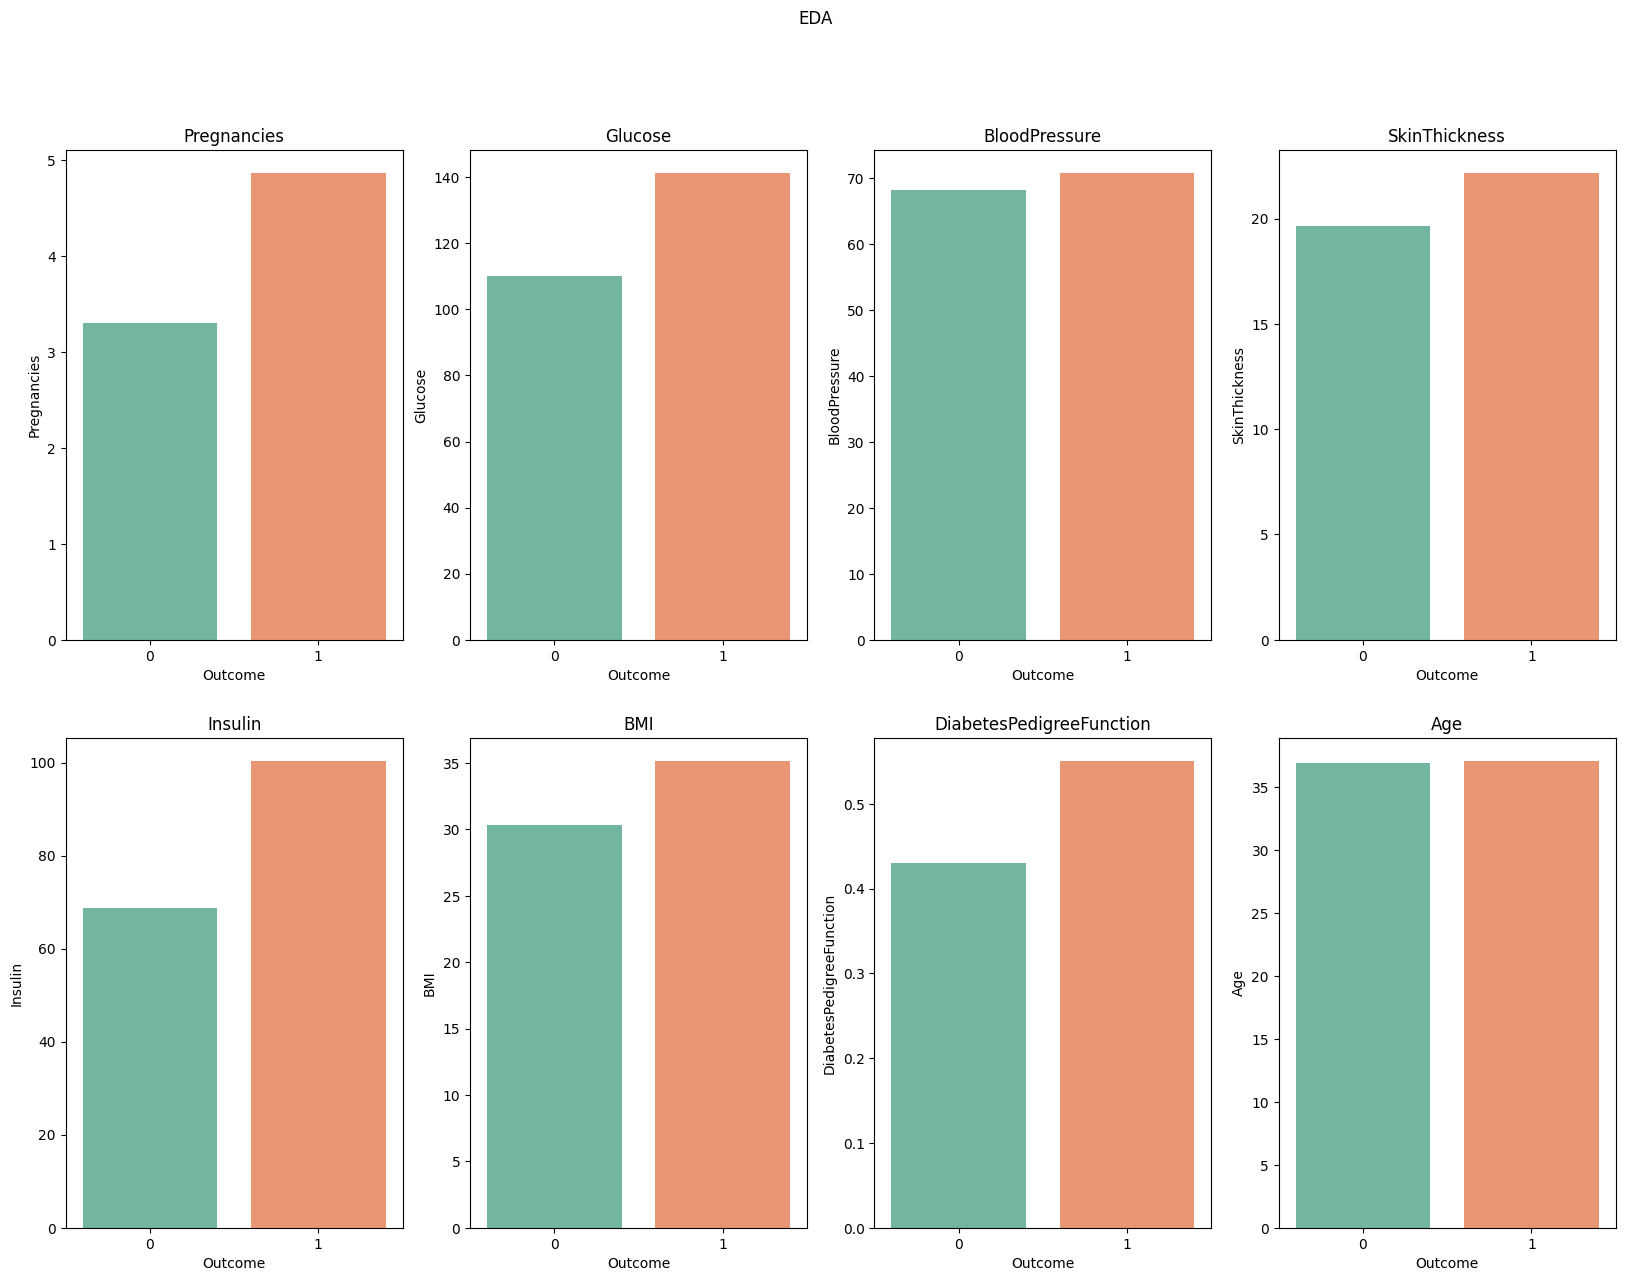

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20,14))


for i in range(4) :
    sns.barplot(x=diabetes.index, y=diabetes.iloc[:,i], ax=axes[0][i], palette='Set2')
    axes[0][i].set_title(diabetes.columns[i])

for i in range(4) :
    sns.barplot(x=diabetes.index, y=diabetes.iloc[:,i+4], ax=axes[1][i], palette='Set2')
    axes[1][i].set_title(diabetes.columns[i+4])

plt.suptitle("EDA")

In [6]:
# EDA를 해석하면 다음과 같다.
# (1) 당뇨병이 있는 사람은 없는 사람보다 pregnancies의 평균 수치가 높다.
# (2) 당뇨병이 있는 사람은 없는 사람보다 glucose의 평균수치가 높다
# (3) 당뇨병이 있는 사람은 없는 사람보다 insulin의 평균수치가 높다
# (4) 당뇨병이 있는 사람은 없는 사람보다 BMI의 평균수치가 높다.

In [7]:
# 종속변수에 딸느 독립변수의 분포를 시각화하여 보았다면, 각 변수들의 상관관계를 시각화하여
# 다중공선성의 문제가 있지는 않은지 파악할수있다

<Axes: >

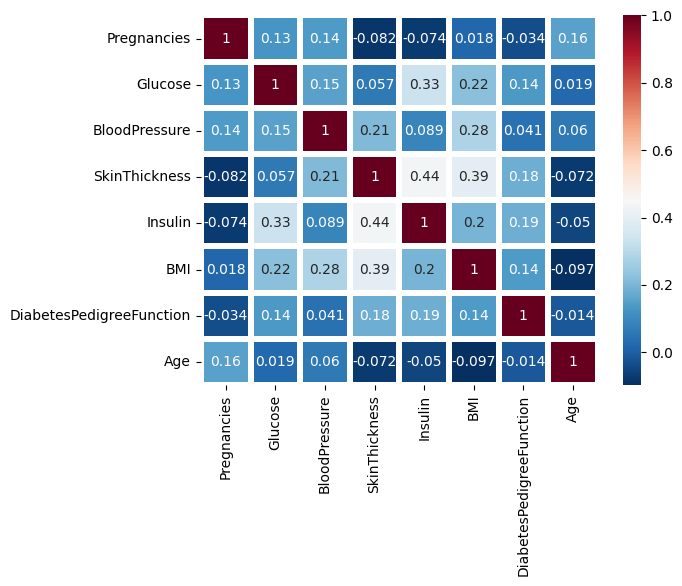

In [8]:
import seaborn as sns

df_cor = df1.drop(columns=['Outcome']).corr(method='pearson')
sns.heatmap(df_cor,
            xticklabels = df_cor.columns,
            yticklabels = df_cor.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=3)

In [9]:
# Outcome을 제외한 변수들간의 상관성을 보았을때, 0.9이상의 상관관계를 가지는 변수는 없었다.
# 그러므로 모든 변수를 사용하여 모델링 해도 될것으로 판단된다.

In [10]:
# (2) 이상치를 식별하고 처리하시오
df1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,36.980469,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,61.404453,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,999.000000,1.000000


In [11]:
X = df1.drop(columns=['Outcome'])
df_v1 = pd.melt(X, var_name='col', value_name='value')
df_v1

,col,value
0,Pregnancies,6.0
1,Pregnancies,1.0
2,Pregnancies,8.0
3,Pregnancies,1.0
4,Pregnancies,0.0
...,...,...
6139,Age,63.0
6140,Age,27.0
6141,Age,30.0
6142,Age,47.0


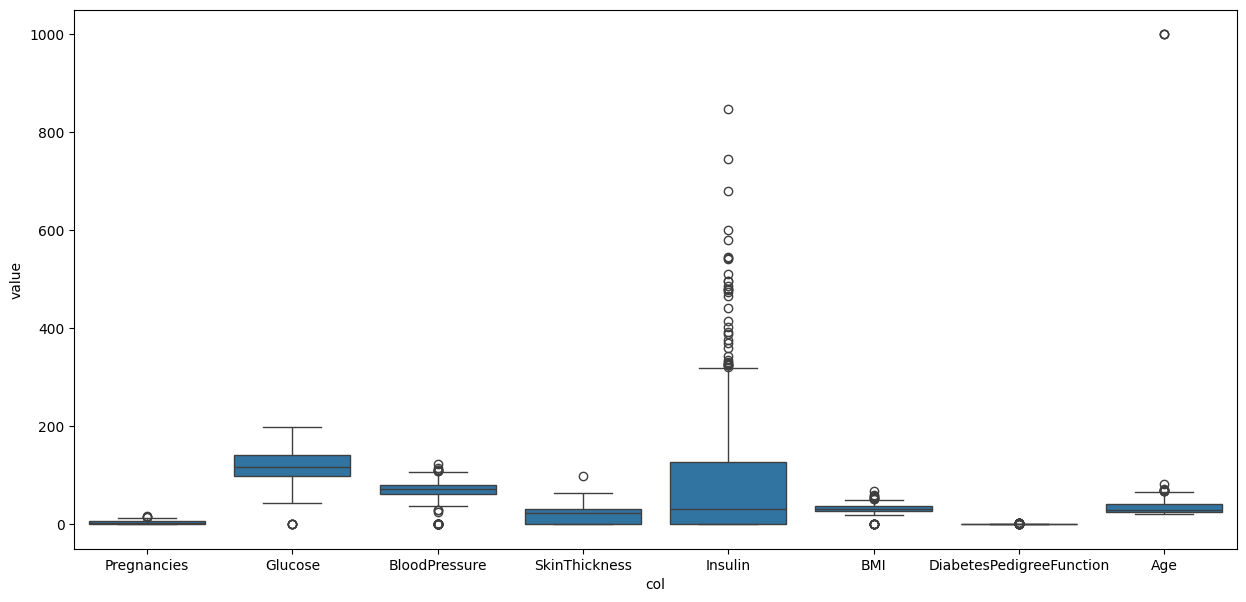

In [12]:
plt.figure(figsize=(15,7))
sns.boxplot(x='col', y='value', data=df_v1)
plt.xticks(range(8), X.columns)
plt.show()

In [13]:
# age컬럼과 같이 눈에 띄는 이상치가 있을때에는 중앙값 혹은 평균값으로 이상치를 대체해줄수있다.
# 결측치 대체와 마찬가지로 이상치가 존재하는 경우 이상치를 제 1회 모의고사 풀이와 같이 knn으로 대체해주어도 된다.

Age의 중앙값: 29.0


<Axes: ylabel='Age'>

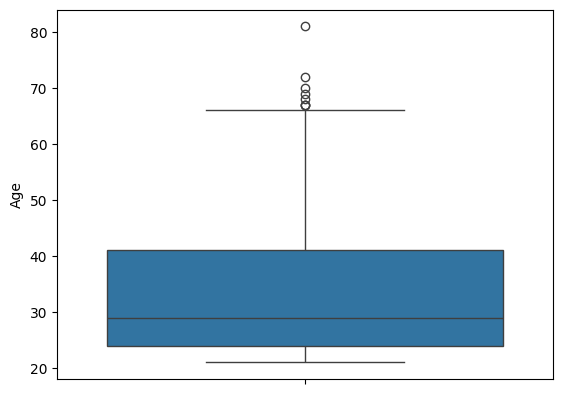

In [14]:
print('Age의 중앙값:', df1.Age.median())
outlier_index = df1[df1['Age']>400].index
df1.loc[outlier_index, 'Age']=df1.Age.median()
sns.boxplot(df1['Age'])

In [15]:
#추가적으로 데이터를 살펴보았을때, glucose 와 bloodpressure에는 0이 존재하지않아야 된다고 판단되었다.
# 이를 이상치라고 판단하여 이상치를 제외한 중앙값으로 이상치를 대체하였다.

In [16]:
outlier_index = df1[df1['Glucose']==0].index
df1.loc[outlier_index, 'Glucose'] = df1.Glucose.median()
outlier_index = df1[df1['BloodPressure']==0].index
df1.loc[outlier_index,'BloodPressure'] = df1.BloodPressure.median()

df1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,20.536458,79.799479,31.992578,0.471876,33.191406,0.348958
std,3.369578,30.438286,12.096642,15.952218,115.244002,7.884160,0.331329,11.683509,0.476951
min,0.000000,44.000000,24.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
# (3) 앞선 두단계에서 발전한 향후분석시에 고려해야 할 사항을 작성하시오.
# 위 describe()함수를 보게되면, 최솟값과 최댓값의 차이가 많이나는 컬럼이 존재한다.
# 따라서 선형 모델 사용시 scale을 적용할 필요가 있어보인다 

In [18]:
# 2.클래스 불균형 처리
# (1)업 샘플링 과정을 설명하고 결과를 작성하시오.

# 오버 샘플링 기법은 비중이 데이터를 추가로 생성해 수를 늘려 데이터 불균형을 극복하는 방식으로,
# 소수레이블을 가진 데이터 세트를 다수레이블을 가진 데이터세트의 수만큼 증식시켜 학습에 충분한 데이터를 확보하는 기법이다.
# 언더샘플링은 데이터 손실의 문제로 인해 예측성능이 저하되는 단점이 있으므로, 일반적으로는 불균형한 데이터를 처리하는 방식으로 
# 오버샘플링을 사용한다.

# <1>Random Oversampling
# ㄱ.소수 클래스에 속하는 데이터의 관측치를 복사하는 방식으로 데이터를 증식한다.
# ㄴ.데이터를 단순복사하는 방식이므로 기존의 데이터와 동일한 복제데이터를 생성한다.
# ㄷ.Random Oversampling은 소수클래스에 과적합이 발생한 가능성이 있다는 단점이 있지만, 사용방법이 간단하다는 장점이 있다.

# <2> SMOTE
# ㄱ. SMOTE는 적은 데이터 세트에 있는 개별데이터들의 K-최근접 이웃을 찾아, 해당 데이터와 K개 이웃들의 차이를 
#     일정한 값으로 만들어 기존 데이터와 약간의 차이를 지닌 새로운 데이터를 생성하는 방식이다.
# ㄴ. SMOTE는 Resampling방식보다 처리속도가 느리다는 단점이있지만, 데이터를 단순히 동일하게 증식시키는 방식이 아니기 때문에,
#     과적합 문제를 예방할수있다는 장점이있다.


In [19]:
df1['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

In [21]:
# !pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [26]:
from imblearn.over_sampling import RandomOverSampler



In [27]:
X = df1.drop(['Outcome'], axis=1)
y = df1[['Outcome']]

ros = RandomOverSampler()
X_upsampling, y_upsampling = ros.fit_resample(X,y)

print('기존의 타깃 분포')
print(df1['Outcome'].value_counts()/len(df1))
print('-'*10)
print('upsampling의 타깃 분포')
print(y_upsampling['Outcome'].value_counts()/len(y_upsampling))

기존의 타깃 분포
Outcome
0    0.651042
1    0.348958
Name: count, dtype: float64
----------
upsampling의 타깃 분포
Outcome
1    0.5
0    0.5
Name: count, dtype: float64


In [ ]:
# (2)언더 샘플링 과정을 설명하고 결과를 작성하시오.

# Undersampling은 다수 클래스를 감소시켜 소수클래스 개수에 맞추는 방식으로, 대표적으로 random으로 다수의 클래스의 데이터를 
# 선택하여 삭제하는 RandomUnderSampler, 서로 다른 클래스가 있을때  서로 다른 클래스에 가장 가까운 데이터들이 토멕 링크로 묶여서 
# 토멕링크중 다수클래스의 데이터를 제거하는 Tomek link방식이 있다.

In [28]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_undersampling, y_undersampling = rus.fit_resample(X,y)

print('기존의 타깃 분포')
print(df1['Outcome'].value_counts()/len(df1))
print('-'*10)
print('undersampling의 타깃 분포')
print(y_undersampling['Outcome'].value_counts()/len(y_undersampling))

기존의 타깃 분포
Outcome
0    0.651042
1    0.348958
Name: count, dtype: float64
----------
undersampling의 타깃 분포
Outcome
0    0.5
1    0.5
Name: count, dtype: float64


In [ ]:
# (3)둘 중 하나를 선택하고 선택한 이유를 서술하시오.

# 해당데이터에서는 oversampling이 적합하다. 데이터가 총 768개로 당뇨병 환자를 대표하깅에는 너무 적은 data이다.
# 심지어 환자의 수는 768명 중 268명뿐이다. undersampling을 선택하게 되면 전체 데이터가 더 적어지기 때문에
# 오버피팅이 일어날 위험이 더 크므로 oversampling을 선택하였다.


In [36]:
# 3. 모델링

# (1) 당뇨병 환자를 예측하는 최소3개 이상의 알고리즘을 제시하고 정확도 측면의 모델 1개와 속도측면의 모델 1개를 제시하시오.
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import sklearn.svm as svm

log = LogisticRegression()
xgb = XGBClassifier(random_state=0)
svm_clf = svm.SVC(kernel='linear')

# 속도 측면에서 logistic regression, 정확도 측면에서 svm, 기타로 xgboost를 제시한다.

In [37]:
# (2) 모델을 비교하고 결과를 설명하시오.

# 해당 모델들을 데이터에 맞게 적용시키고 비교하기위해 아래와 같이 객체화시켰다.

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import time
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=0)

# 5개의 경우의 수로 분할하여 검증
kfold = KFold()
def model_result(model):
    pred_li = []
    for train_index, test_index in kfold.split(X):
        X_train, X_test = X.iloc[train_index,:],X.iloc[test_index,:]
        y_train, y_test = y.iloc[train_index,:],y.iloc[test_index,:]

        X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)

        start = time.time()
        model.fit(X_train_resample, y_train_resample)
        end = time.time()

        pred = model.predict(X_test)
        pred_li.append(accuracy_score(pred, y_test['Outcome']))

    ## 마지막 데이터 학습속도
    print(f'{end - start:.5f} sec')
    ## 5개의 train데이터에 대한 정확도의 평균 값
    print(np.mean(pred_li))

In [38]:
model_result(log)

0.01652 sec
0.7474832357185297


In [39]:
model_result(xgb)

0.04488 sec
0.743519225872167


In [40]:
model_result(svm_clf)

2.73466 sec
0.7618198794669383


In [41]:
# (3) 속도개선을 위한 차원축소 방법을 설명하고 수행하시오. 그리고 예측 성능과 속도를 비교하고 결과를 작성하시오.

# 속도 개선을 위한 차원축소방법인 pca를 사용할수있다. 예측의 성능은 원본의 데이터를 그대로 사용하는 것보다 떨어질수있지만,
# 차원을 축소함으로써 예측의 속도는 훨씬 상승시킬수있다.pca를 사용할때, 데이터 스케일에 따라 각 주성분이 설명가능한 분산량이 
# 달라질수있기때문에 데이터스케일링을 꼭 해주어야 한다.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=2022)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
pca = PCA(n_components=8)
X_train_pca = pca.fit(X_train_s)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_[:5].sum())

[0.26110315 0.22613628 0.12025873 0.10650649 0.1016306  0.08197042
 0.05251497 0.04987936]
0.815635246354633


In [44]:
# 이제 5개의 주성분을 가지고 모델링을 하는 코드를 작성해보자.
def pca_model_result(model):
    pred_li = []
    for train_index, test_index in kfold.split(X):
        X_train, X_test = X.iloc[train_index,:], X.iloc[test_index,:]
        y_train, y_test = y.iloc[train_index,:], y.iloc[test_index,:]

        X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)

        scaler = StandardScaler()
        X_train_res_s = scaler.fit_transform(X_train_resample)
        X_test_s = scaler.transform(X_test)

        pca = PCA(n_components=5)
        X_train_pca = pca.fit_transform(X_train_res_s)
        X_test_pca = pca.transform(X_test_s)

        start = time.time()
        model.fit(X_train_pca, y_train_resample)
        end = time.time()

        pred = model.predict(X_test_pca)
        pred_li.append(accuracy_score(pred, y_test['Outcome']))

    
    print(f"{end - start:.5f} sec")
    print(np.mean(pred_li))

In [46]:
pca_model_result(log)

0.00197 sec
0.7279093455564045


In [47]:
pca_model_result(xgb)

0.04687 sec
0.713598166539343


In [48]:
pca_model_result(svm_clf)

0.01396 sec
0.7253034547152193
